### DSA2101 AY25/26 Finals

In [1]:
from datetime import datetime
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from plotnine import *

In [2]:
t1 = pd.read_excel('../data/final_t1.xlsx', skiprows = 3)
t2 = pd.read_excel('../data/final_cruises_t2.xlsx', sheet_name = 'Revenue', skiprows = 1)
t3 = pd.read_excel('../data/final_continents_t3.xlsx')

Q1

In [3]:
t2 = t2[0:76]
t2[2017] = t2[2017].astype('float')
t2 = t2.rename(columns = {2017: '2017'})
plot1 = t2.copy()
countries = ['Indonesia', 'Japan', 'Malaysia', 'Singapore']
plot1 = plot1[plot1['Country'].isin(countries)]
plot1 = plot1.set_index('Country')
plot1.head()

,2017,2018,2019,2020,2021,2022,2023,2024,2025
Country,,,,,,,,,
Indonesia,22.0,22.0,22.0,5.0,2.0,12.0,19.0,21.0,23.0
Japan,314.0,329.0,330.0,76.0,5.0,41.0,232.0,252.0,266.0
Malaysia,90.0,94.0,98.0,23.0,8.0,53.0,297.0,321.0,344.0
Singapore,233.0,328.0,390.0,90.0,170.0,443.0,437.0,469.0,479.0


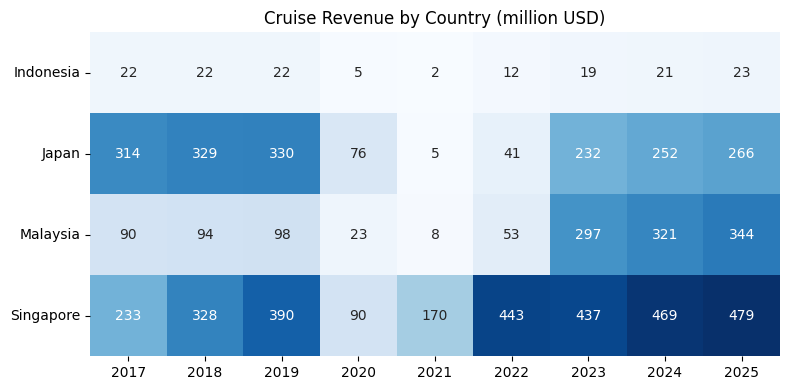

In [4]:
fig, ax = plt.subplots(figsize = (8, 4))
ax = sns.heatmap(plot1, annot = True, cmap = 'Blues', cbar = False, fmt = '.0f')
ax.set(title = 'Cruise Revenue by Country (million USD)',
       ylabel = '')
plt.yticks(rotation = 0)
fig.tight_layout()
plt.show()

Q2

In [5]:
t2.head()

,Country,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Algeria,5.0,5.0,5.0,1.0,1.0,3.0,5.0,6.0,6.0
1,Armenia,6.0,6.0,7.0,2.0,1.0,4.0,7.0,7.0,8.0
2,Australia,964.0,1007.0,1049.0,248.0,2.0,364.0,1206.0,1323.0,1409.0
3,Austria,109.0,115.0,116.0,27.0,5.0,41.0,96.0,105.0,111.0
4,Bahrain,7.0,8.0,9.0,2.0,1.0,6.0,9.0,10.0,10.0


In [6]:
t3 = t3.rename(columns = {'name' : 'Country'})
t3.head()

,Country,continent
0,Afghanistan,Asia
1,Albania,Europe
2,Algeria,Africa
3,Andorra,Europe
4,Angola,Africa


In [7]:
plot2 = t2.merge(t3, how = 'left', on = 'Country')
plot2 = plot2.groupby('continent')['2020'].sum().reset_index()
plot2 = plot2.sort_values('2020', ascending = False)
plot2

,continent,2020
3,North America,4647.0
2,Europe,2100.0
1,Asia,785.0
4,Oceania,248.0
5,South America,93.0
0,Africa,16.0


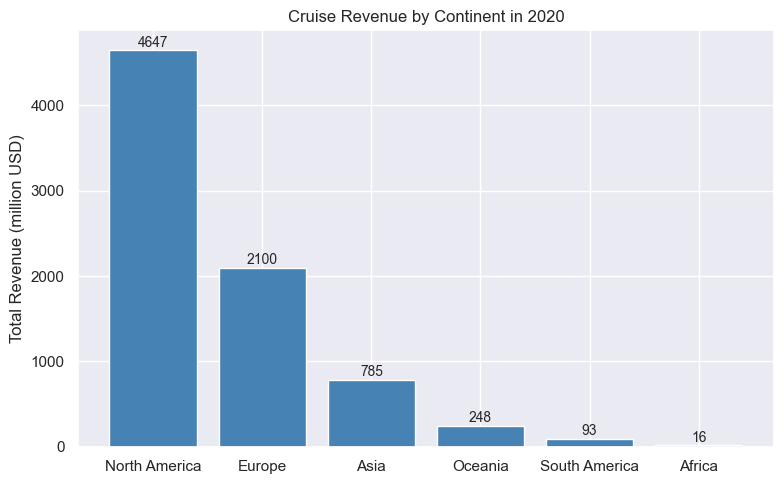

In [8]:
sns.set_theme(style = 'darkgrid')
fig, ax = plt.subplots(figsize = (8, 5))
bars = ax.bar(plot2['continent'], plot2['2020'], color = 'steelblue')
ax.set(title = 'Cruise Revenue by Continent in 2020',
       ylabel = 'Total Revenue (million USD)',
       xlabel = '')
ax.bar_label(bars, padding = 0.5, fontsize = 10)
fig.tight_layout()
plt.show()

Q3

In [9]:
plot3 = t2.merge(t3, how = 'left', on = 'Country').copy()
plot3 = plot3.groupby('continent')[['2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']].mean().reset_index()
plot3 = plot3.melt(id_vars= 'continent', var_name = 'year', value_name = 'mean revenue')
plot3 = plot3.pivot(index = 'year', columns = 'continent', values = 'mean revenue').reset_index()
plot3.columns.name = None
plot3

,year,Africa,Asia,Europe,North America,Oceania,South America
0,2017,13.4,141.363636,246.264706,2839.166667,964.0,43.500
1,2018,13.6,151.090909,256.088235,3190.333333,1007.0,46.000
2,2019,14.2,152.136364,267.764706,3419.333333,1049.0,50.250
3,2020,3.2,35.681818,61.764706,774.500000,248.0,11.625
4,2021,2.0,13.818182,26.500000,306.166667,2.0,3.875
5,2022,8.6,38.727273,173.029412,2312.666667,364.0,26.250
6,2023,13.2,81.500000,287.382353,4111.000000,1206.0,64.250
7,2024,14.8,110.727273,310.500000,4502.500000,1323.0,69.625
8,2025,16.6,117.363636,327.588235,4856.833333,1409.0,73.500


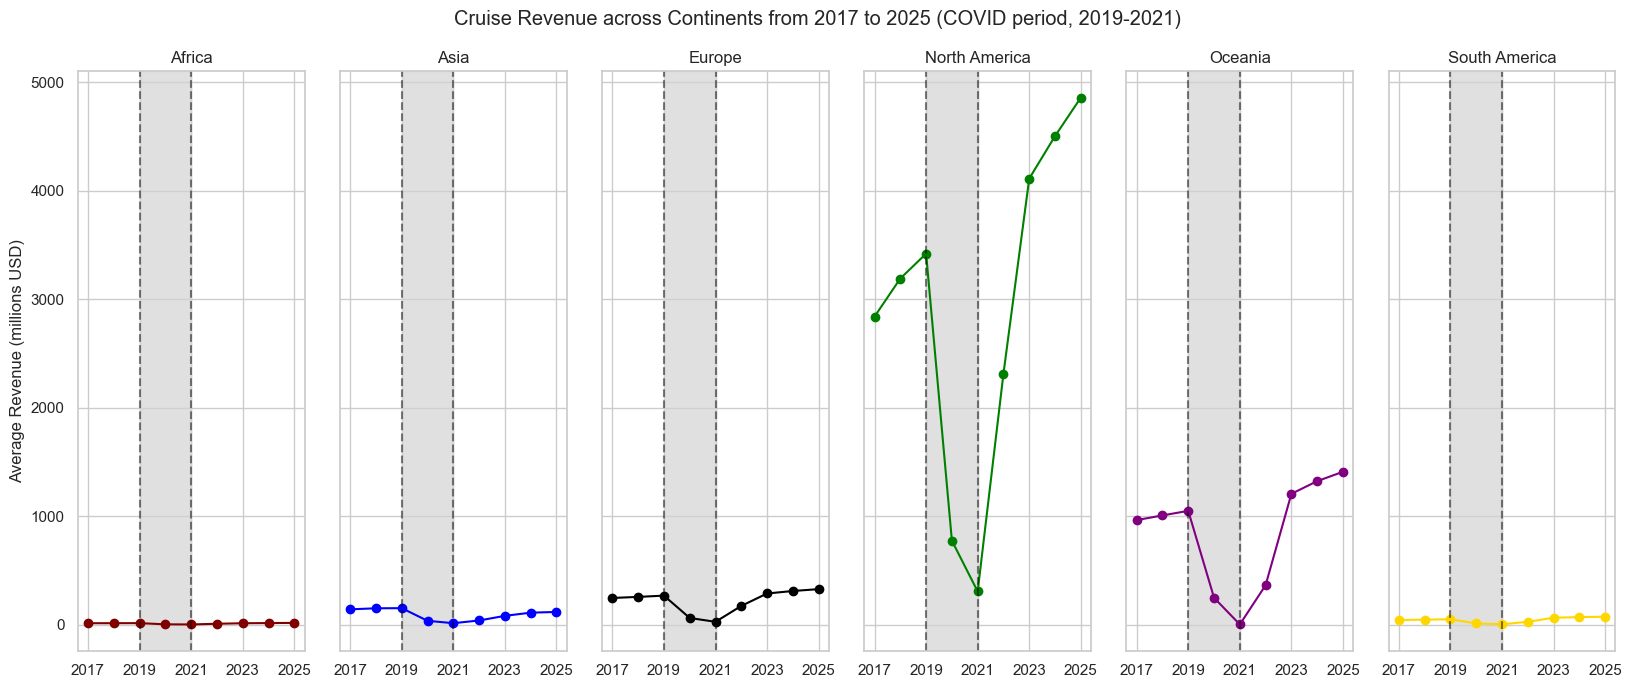

In [10]:
sns.set_theme(style = 'whitegrid')
fig, axes = plt.subplots(1, 6, figsize = (16.5, 7), sharex = True, sharey = True)
continents = ['Africa', 'Asia', 'Europe', 'North America', 'Oceania', 'South America']
colors = ['maroon', 'blue', 'black', 'green', 'purple', 'gold']


for ax, continent, color in zip(axes, continents, colors):
    ax.plot(plot3['year'], plot3[continent], color = color, marker = 'o')
    ax.set(title = continent)
    ax.set_xticks(['2017', '2019', '2021', '2023', '2025'])
    ax.axvline('2019', ls = '--', color = 'black', alpha = 0.5)
    ax.axvline('2021', ls = '--', color = 'black', alpha = 0.5)
    ax.axvspan('2019', '2021', color = 'lightgrey', alpha = 0.7)


axes[0].set(ylabel = 'Average Revenue (millions USD)')
fig.suptitle('Cruise Revenue across Continents from 2017 to 2025 (COVID period, 2019-2021)')
fig.tight_layout()
plt.show()